In [11]:
import torch as T
import numpy as np
import tqdm
from matplotlib import pyplot as plt

device = T.device('cpu')

In [12]:
import PIL

horizon = 32

img = np.array(PIL.Image.open('cat.png').resize((horizon,horizon)))
logdensity = T.from_numpy(np.log(1+ img)).flatten().float()

In [13]:

ndim = 2

n_hid = 256
n_layers = 2

detailed_balance = False
uniform_pb = True

def make_mlp(l, act=T.nn.LeakyReLU(), tail=[]):
    return T.nn.Sequential(*(sum(
        [[T.nn.Linear(i, o)] + ([act] if n < len(l)-2 else [])
         for n, (i, o) in enumerate(zip(l, l[1:]))], []) + tail))

def log_reward(x):
    # ax = abs(x / (horizon-1) * 2 - 1)
    # return ((ax > 0.5).prod(-1) * 0.5 + ((ax < 0.8) * (ax > 0.6)).prod(-1) * 2 + 1e-1).log()
    x_ = x @ (horizon ** T.arange(ndim)).float()
    return logdensity[x_.long()]

j = T.zeros((horizon,)*ndim+(ndim,))
for i in range(ndim):
    jj = T.linspace(0,horizon-1,horizon)
    for _ in range(i): jj = jj.unsqueeze(1)
    j[...,i] = jj

truelr = log_reward(j)
print('total reward', truelr.view(-1).logsumexp(0))
true_dist = truelr.flatten().softmax(0).cpu().numpy()

total reward tensor(11.8279)


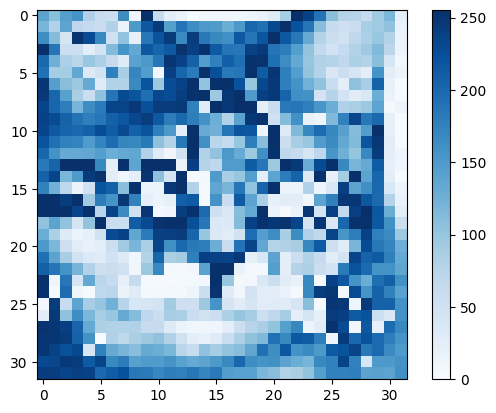

In [14]:
plt.imshow(truelr.exp().numpy(), cmap='Blues', vmin=0)
plt.colorbar()

In [15]:
def toin(z):
    return T.nn.functional.one_hot(z, horizon).view(z.shape[0],-1).float()

def modeled_density():
    with T.no_grad():
        m = T.zeros((horizon,horizon))
        f = T.zeros((horizon,horizon))
        f[0,0] = 1
        for i in range(horizon):
            zs = T.zeros((horizon,2)).long()
            zs[:,0] = i
            zs[:,1] = T.arange(horizon)
            logits = model(toin(zs))[...,:3]
            edge_mask = T.cat([ (zs==horizon-1).float(), T.zeros((horizon,1), device=device) ], 1) 
            probs = ( logits - 100000000000*edge_mask ).softmax(1)
            for j in range(horizon):
                m[i,j] += f[i,j] * probs[j,2]
                if i<horizon-1: f[i+1,j] += f[i,j] * probs[j,0]
                if j<horizon-1: f[i,j+1] += f[i,j] * probs[j,1]
    return m

In [16]:
# Seed
np.random.seed(0)
T.manual_seed(0)

Z = T.zeros((1,)).to(device)
if detailed_balance:
    model = make_mlp([ndim*horizon] + [n_hid] * n_layers + [2*ndim+2]).to(device)
    opt = T.optim.Adam([ {'params':model.parameters(), 'lr':0.001} ])
else:
    model = make_mlp([ndim*horizon] + [n_hid] * n_layers + [2*ndim+2]).to(device)
    opt = T.optim.Adam([ {'params':model.parameters(), 'lr':0.001}, {'params':[Z], 'lr':0.1} ])
    Z.requires_grad_()

 32%|███▏      | 97/300 [00:03<00:07, 27.20it/s]

loss = 2.5594450956583024
Reverse KL = 0.2851613759994507
Forward KL = 0.24109919369220734


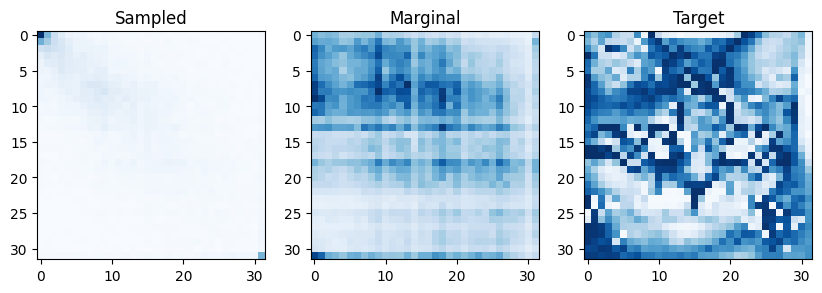

 66%|██████▋   | 199/300 [00:07<00:04, 24.94it/s]

loss = 0.5688504213094712
Reverse KL = 0.15859419107437134
Forward KL = 0.14102700352668762


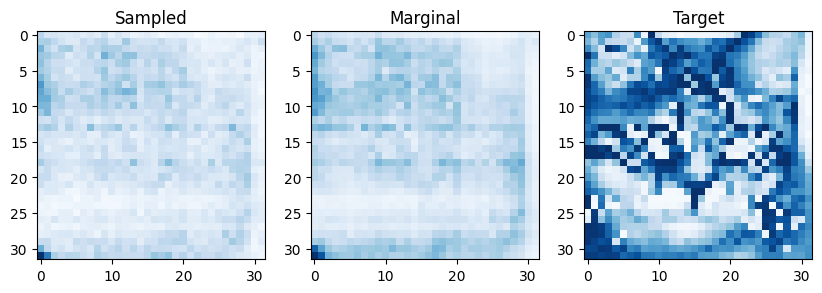

 99%|█████████▉| 298/300 [00:11<00:00, 24.96it/s]

loss = 0.32300274550914765
Reverse KL = 0.09353257715702057
Forward KL = 0.09154222905635834


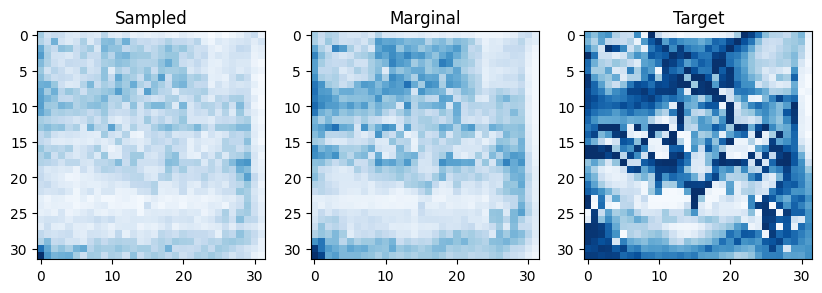

100%|██████████| 300/300 [00:11<00:00, 25.75it/s]


In [ ]:
losses = []
all_visited = []
resample = False
resample_every = -1

traj_len_history = []
weights_history = []

bs = 256
iter = 300
T.set_grad_enabled(True)
for it in tqdm.trange(1, iter + 1):
    opt.zero_grad()
    
    z = T.zeros((bs, ndim), dtype=T.long).to(device)
    done = T.full((bs,), False, dtype=T.bool).to(device)
        
    action = None
    
    logf = T.zeros((ndim*horizon+1, bs)).to(device)
    logpf = T.zeros((ndim*horizon, bs)).to(device)
    logpb = T.zeros((ndim*horizon, bs)).to(device)
    
    i = 0
    while T.any(~done):
        
        pred = model(toin(z[~done]))
        
        edge_mask = T.cat([ (z[~done]==horizon-1).float(), T.zeros(((~done).sum(),1), device=device) ], 1)
        logits = (pred[...,:ndim+1] - 1000000000*edge_mask).log_softmax(1)

        init_edge_mask = (z[~done]== 0).float()
        back_logits = ( (0 if uniform_pb else 1)*pred[...,ndim+1:2*ndim+1] - 1000000000*init_edge_mask).log_softmax(1)  # Need to check
        
        log_flow = pred[...,2*ndim+1]
        # if i>0 or detailed_balance: 
        #     logf[i,~done] = log_flow + log_reward(z[~done].float())  # DB with using reward information at every step
        # else: logf[i,~done] += Z
        logf[i,~done] = log_reward(z[~done].float()) - logits[:,ndim]
        
        if action is not None:
            logpb[i-1,~done] = back_logits.gather(1, action[action!=ndim].unsqueeze(1)).squeeze(1)

        # if resample and resample_every > 0 and i % resample_every == 0:
        #     cum_iw = - ( logf[0]+logpf.sum(0)-logf[i]-logpb.sum(0) )[~done]
        #     # weights = cum_iw.softmax(0).clamp(min=1./((~done).sum())**1.5)
        #     weights = cum_iw.softmax(0).clamp(max=1./((~done).sum())**1.5)
        #     sample = T.distributions.Categorical(weights).sample(((~done).sum(),))
        #     z[~done] = z[~done][sample]
        #     logf[:,~done] = logf[:,~done][:,sample]
        #     logpf[:,~done] = logpf[:,~done][:,sample]
        #     logpb[:,~done] = logpb[:,~done][:,sample]
        #     logits = logits[sample]

        # if T.all(done): break
        # # todo: avoid recomputing
        # pred = model(toin(z[~done]))
        # edge_mask = T.cat([ (z[~done]==horizon-1).float(), T.zeros(((~done).sum(),1), device=device) ], 1)
        # logits = (pred[...,:ndim+1] - 1000000000*edge_mask).log_softmax(1)

        exp_weight= 0.
        temp = 1
        sample_ins_probs = (1-exp_weight)*(logits/temp).softmax(1) + exp_weight*(1-edge_mask) / (1-edge_mask+0.0000001).sum(1).unsqueeze(1)
        
        action = sample_ins_probs.multinomial(1)
        logpf[i,~done] = logits.gather(1, action).squeeze(1)

        with T.no_grad():
            terminate = (action==ndim).squeeze(1)

            done[~done] |= terminate
            logf[i+1:,done] = log_reward(z[done].float())  

        with T.no_grad():
            z[~done] = z[~done].scatter_add(1, action[~terminate], T.ones(action[~terminate].shape, dtype=T.long, device=device))

        
        i += 1

    for x in z:
        state = (x.cpu()*(horizon**T.arange(ndim))).sum().item()
        all_visited.append(state)

    # z_save = z.clone()
    # if resample:
    #     err = - ( logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0) )
    #     # iw = err
    #     iw =  err + (err**2).log()
    #     weights = iw.softmax(0)#.clamp(max=1./bs**1.5)
    #     sample = T.distributions.Categorical(weights).sample((bs,))
    #     z = z[sample]
    #     logf = logf[:,sample]
    #     logpf = logpf[:,sample]
    #     logpb = logpb[:,sample]
    
    if detailed_balance:
        lens = z.sum(1)+1
        loss = (logf[:-1]+logpf-logf[1:]-logpb).pow(2).sum()/lens.sum() 
    else:
        weights = T.ones(bs).to(device)
        if resample and i % resample_every == 0:
            err = - ( logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0) )
            weights = err.softmax(0)

        loss = (weights * (logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0)).pow(2)).sum()/bs
        
    loss.backward()

    opt.step()

    losses.append(loss.item())

    if it%100==0: 
        print('loss =', np.array(losses[-100:]).mean())#, 'Z =', logf[0,0].item())
        emp_dist = np.bincount(all_visited[-100*bs:], minlength=len(true_dist)).astype(float)
        emp_dist /= emp_dist.sum()
        md = modeled_density().T
        mdsm = md.flatten().log().log_softmax(0)
        truesm = truelr.flatten().log_softmax(0)
        print('Reverse KL =', -(mdsm.exp() * (truesm-mdsm)).sum().item())
        print('Forward KL =', -(truesm.exp() * (mdsm-truesm)).sum().item())
        plt.figure(figsize=(10,3))
        plt.subplot(1,3,1);plt.title('Sampled')
        plt.imshow(emp_dist.reshape(horizon,horizon), cmap='Blues', vmin=0)
        plt.subplot(1,3,2);plt.title('Marginal')
        plt.imshow(md, cmap='Blues', vmin=0)
        plt.subplot(1,3,3);plt.title('Target')
        plt.imshow(truelr.exp().numpy(), cmap='Blues', vmin=0)
        plt.show()

L1 dist (modeled) = 0.27617416
Reverse KL (modeled) = 0.09353257715702057
Forward KL (modeled) = 0.09154222905635834

Empirical L1 dist = 0.36263844214485363
Empirical Reverse KL = 0.13491938044674184
Empirical Forward KL = 0.1821856088425321

Empirical L1 dist (resampled) = 0.34539192137334535
Empirical Reverse KL (resampled) = 0.10385179112318847
Empirical Forward KL (resampled) = 0.27217048176997527



/var/folders/kp/tqcmcz3n50nbs5mr__kb16f80000gn/T/ipykernel_10236/10076727.py:81: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print('Empirical Forward KL =', -(truesm.exp() * (empsm-truesm.detach().cpu().numpy())).sum().item())
/var/folders/kp/tqcmcz3n50nbs5mr__kb16f80000gn/T/ipykernel_10236/10076727.py:104: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print('Empirical Forward KL (resampled) =', -(truesm.exp() * (empsm_resampled-truesm.detach().cpu().numpy())).sum().item())


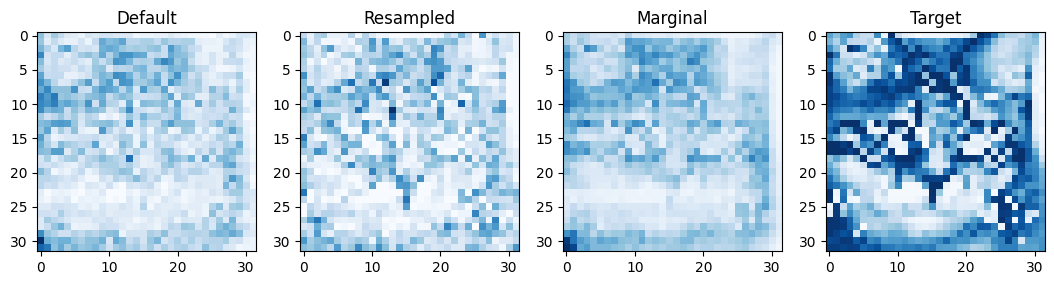

In [18]:
all_visited = []
all_visited_resampled = []

bs = 10000
T.set_grad_enabled(False)

z = T.zeros((bs, ndim), dtype=T.long).to(device)
done = T.full((bs,), False, dtype=T.bool).to(device)
    
action = None

logf = T.zeros((ndim*horizon+1, bs)).to(device)
logpf = T.zeros((ndim*horizon, bs)).to(device)
logpb = T.zeros((ndim*horizon, bs)).to(device)

i = 0
while T.any(~done):
    
    pred = model(toin(z[~done]))
    
    edge_mask = T.cat([ (z[~done]==horizon-1).float(), T.zeros(((~done).sum(),1), device=device) ], 1)
    logits = (pred[...,:ndim+1] - 1000000000*edge_mask).log_softmax(1)

    init_edge_mask = (z[~done]== 0).float()
    back_logits = ( (0 if uniform_pb else 1)*pred[...,ndim+1:2*ndim+1] - 1000000000*init_edge_mask).log_softmax(1)  # Need to check
    
    log_flow = pred[...,2*ndim+1]
    # if i>0 or detailed_balance: 
    #     logf[i,~done] = log_flow + log_reward(z[~done].float())  # DB with using reward information at every step
    # else: logf[i,~done] += Z
    logf[i,~done] = log_reward(z[~done].float()) - logits[:,ndim]
    
    if action is not None:
        logpb[i-1,~done] = back_logits.gather(1, action[action!=ndim].unsqueeze(1)).squeeze(1)


    # if T.all(done): break
    # # todo: avoid recomputing
    # pred = model(toin(z[~done]))
    # edge_mask = T.cat([ (z[~done]==horizon-1).float(), T.zeros(((~done).sum(),1), device=device) ], 1)
    # logits = (pred[...,:ndim+1] - 1000000000*edge_mask).log_softmax(1)

    exp_weight= 0.
    temp = 1
    sample_ins_probs = (1-exp_weight)*(logits/temp).softmax(1) + exp_weight*(1-edge_mask) / (1-edge_mask+0.0000001).sum(1).unsqueeze(1)
    
    action = sample_ins_probs.multinomial(1)
    logpf[i,~done] = logits.gather(1, action).squeeze(1)

    with T.no_grad():
        terminate = (action==ndim).squeeze(1)

        done[~done] |= terminate
        logf[i+1:,done] = log_reward(z[done].float())  

    with T.no_grad():
        z[~done] = z[~done].scatter_add(1, action[~terminate], T.ones(action[~terminate].shape, dtype=T.long, device=device))

    
    i += 1

for x in z:
    state = (x.cpu()*(horizon**T.arange(ndim))).sum().item()
    all_visited.append(state)

z_save = z.clone()

md = modeled_density().T
mdsm = md.flatten().log().log_softmax(0)
truesm = truelr.flatten().log_softmax(0)
print('L1 dist (modeled) =', np.abs(md.flatten().cpu().numpy()-true_dist).sum())
print('Reverse KL (modeled) =', -(mdsm.exp() * (truesm-mdsm)).sum().item())
print('Forward KL (modeled) =', -(truesm.exp() * (mdsm-truesm)).sum().item())
print()

emp_dist = np.bincount(all_visited[-bs:], minlength=len(true_dist)).astype(float)
emp_dist /= emp_dist.sum()
empsm = np.log(emp_dist + 1e-10)
print('Empirical L1 dist =', np.abs(emp_dist-true_dist).sum())
print('Empirical Reverse KL =', -(emp_dist * (truesm.detach().cpu().numpy()-empsm)).sum().item())
print('Empirical Forward KL =', -(truesm.exp() * (empsm-truesm.detach().cpu().numpy())).sum().item())
print()

# Do resample
err = - ( logf[0]+logpf.sum(0)-logf[-1]-logpb.sum(0) )
iw = err
# iw =  err + (err**2).log()
weights = iw.softmax(0)#.clamp(max=1./bs**1.5)
sample = T.distributions.Categorical(weights).sample((bs,))
z = z[sample]
logf = logf[:,sample]
logpf = logpf[:,sample]
logpb = logpb[:,sample]

for x in z:
    state = (x.cpu()*(horizon**T.arange(ndim))).sum().item()
    all_visited_resampled.append(state)

emp_dist_resampled = np.bincount(all_visited_resampled[-bs:], minlength=len(true_dist)).astype(float)
emp_dist_resampled /= emp_dist_resampled.sum()
empsm_resampled = np.log(emp_dist_resampled + 1e-10)
print('Empirical L1 dist (resampled) =', np.abs(emp_dist_resampled-true_dist).sum())
print('Empirical Reverse KL (resampled) =', -(emp_dist_resampled * (truesm.detach().cpu().numpy()-empsm_resampled)).sum().item())
print('Empirical Forward KL (resampled) =', -(truesm.exp() * (empsm_resampled-truesm.detach().cpu().numpy())).sum().item())
print()

plt.figure(figsize=(13,3))
plt.subplot(1,4,1);plt.title('Default')
plt.imshow(emp_dist.reshape(horizon,horizon), cmap='Blues', vmin=0)
plt.subplot(1,4,2);plt.title('Resampled')
plt.imshow(emp_dist_resampled.reshape(horizon,horizon), cmap='Blues', vmin=0)
plt.subplot(1,4,3);plt.title('Marginal')
plt.imshow(md, cmap='Blues', vmin=0)
plt.subplot(1,4,4);plt.title('Target')
plt.imshow(truelr.exp().numpy(), cmap='Blues', vmin=0)
plt.show()


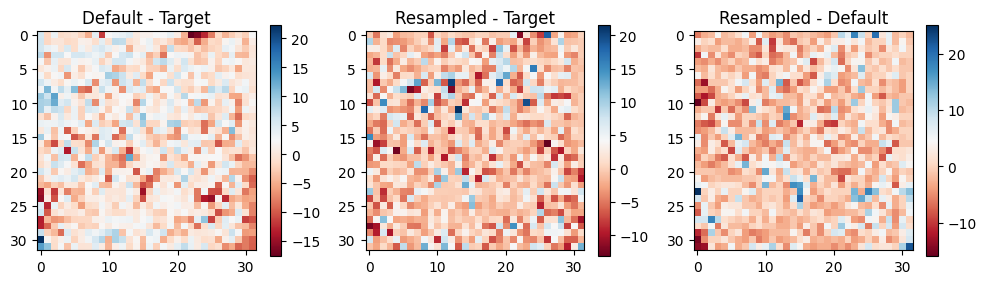

In [19]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1);plt.title('Default - Target')
plt.imshow(((emp_dist - true_dist)*bs).reshape(horizon,horizon), cmap='RdBu')
plt.colorbar()
plt.subplot(1,3,2);plt.title('Resampled - Target')
plt.imshow(((emp_dist_resampled - true_dist)*bs).reshape(horizon,horizon), cmap='RdBu')
plt.colorbar()
plt.subplot(1,3,3);plt.title('Resampled - Default')
plt.imshow(((emp_dist_resampled - emp_dist)*bs).reshape(horizon,horizon), cmap='RdBu')
plt.colorbar()

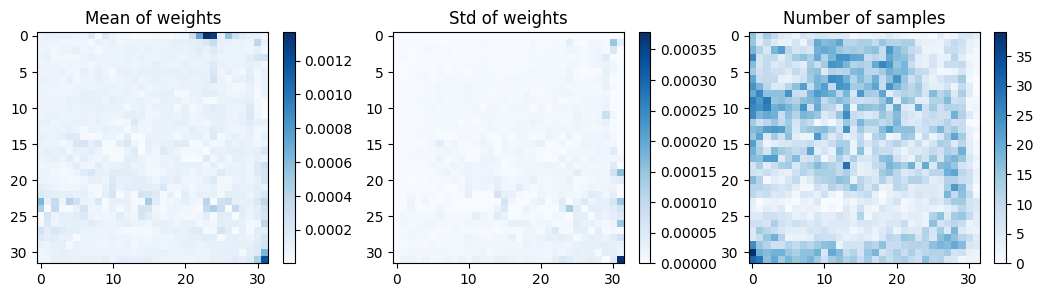

In [22]:
# Check the variance of weights for each terminal state
weight_dict = {}
for x, w in zip(z_save, weights):
    state = (x.cpu()*(horizon**T.arange(ndim))).sum().item()
    if state not in weight_dict:
        weight_dict[state] = []
    weight_dict[state].append(w.item())

mean_dict = {}
std_dict = {}
for state, ws in weight_dict.items():
    mean_dict[state] = np.mean(ws)
    std_dict[state] = np.std(ws)

plt.figure(figsize=(13,3))
plt.subplot(1,3,1)
plt.imshow(np.array([mean_dict.get(state, 1/bs) for state in range(horizon**ndim)]).reshape(horizon, horizon), cmap='Blues')
plt.colorbar()
plt.title('Mean of weights')
plt.subplot(1,3,2)
plt.imshow(np.array([std_dict.get(state, 0) for state in range(horizon**ndim)]).reshape(horizon, horizon), cmap='Blues')
plt.colorbar()
plt.title('Std of weights')
plt.subplot(1,3,3)
plt.imshow(np.array([len(weight_dict.get(state, [])) for state in range(horizon**ndim)]).reshape(horizon, horizon), cmap='Blues')
plt.colorbar()
plt.title('Number of samples')
plt.show()

In [21]:
F(s) = R(s) / P(terminate | s)

SyntaxError: cannot assign to function call here. Maybe you meant '==' instead of '='? (2577269975.py, line 1)

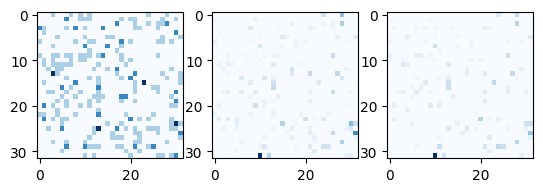

In [ ]:
points = np.zeros((horizon,horizon))
for i,j in z_save:
    points[i,j] += 1
plt.subplot(131)
plt.imshow(points, cmap='Blues', vmin=0)

points = np.zeros((horizon,horizon))
k=0
for i,j in z_save:
    points[i,j] += weights[k].item()
    k+=1
plt.subplot(132)
plt.imshow(points, cmap='Blues', vmin=0)

points = np.zeros((horizon,horizon))
for i,j in z:
    points[i,j] += 1
plt.subplot(133)
plt.imshow(points, cmap='Blues', vmin=0)

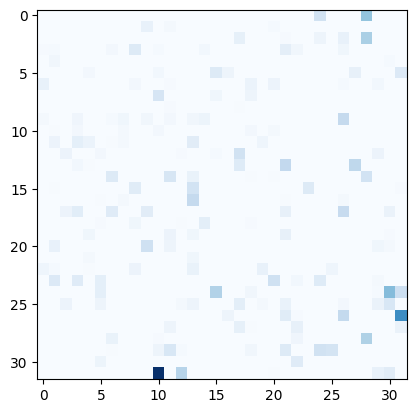

In [ ]:
x[0][0] -> x[0][1] -> ... -> x[0][t] -> x[0][t] -> x[0][t] -> x[0][t] -> x[0][t]
x[1][0] -> x[1][1] -> ... -> x[1][t]
...
x[D][0] -> x[D][1] -> ... -> x[D][t]

<BarContainer object of 16 artists>

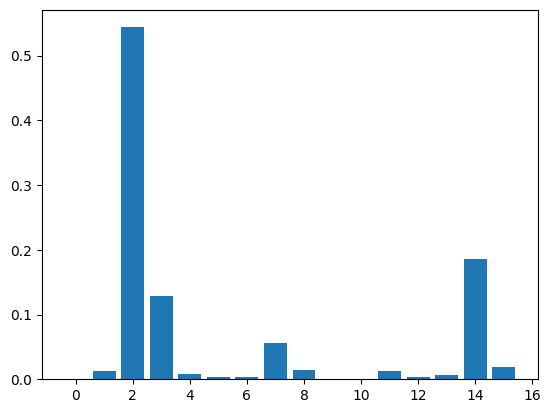

In [ ]:
plt.bar(np.arange(bs),iw.softmax(0).detach())